# DX 601 Week 4 Homework

## Introduction

In this homework, you will perform some outlier detection using z-scoring and infer which model is better according to t-testing

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for sample code.

* https://github.com/bu-cds-omds/dx500-examples
* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Instructions

You should replace every instance of "..." or "TODO" below.
These are where you are expected to write code to answer each problem.

After some of the problems, there are extra code cells that will test functions that you wrote so you can quickly see how they run on an example.
If your code works on these examples, it is more likely to be correct.
However, the autograder will test different examples, so working correctly on these examples does not guarantee full credit for the problem.
You may change the example inputs to further test your functions on your own.
You may also add your own example inputs for problems where we did not provide any.

Be sure to run each code block after you edit it to make sure it runs as expected.
When you are done, we strongly recommend you run all the code from scratch (Runtime menu -> Restart and Run all) to make sure your current code works for all problems.

If your code raises an exception when run from scratch, it will  interfere with the auto-grader process causing you to lose some or all points for this homework.
Please ask for help in YellowDig or schedule an appointment with a learning facilitator if you get stuck.


## Problems

## Shared Imports

Do not install or use any additional modules.
Installing additional modules may result in an autograder failure resulting in zero points for some or all problems.

In [1]:
import math
import random
from pprint import pprint
from typing import Set

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Shared Data

This problem will use one of the provided datasets called "spatial_data.txt." The contents of this file is a matrix (i.e. a table) of data where each row is a sample and each column is a feature. I am doing some pre-processing to this data which you don't have to understand, just that it converts this matrix into a list of floats.

This data set is small and your code should run instantly with it, but you will be able to use the same code and techniques with larger data sets.

In [3]:
# Please don't change this
def load_data() -> np.ndarray:
    X_raw = np.loadtxt("spatial_data.txt")

    # some special conversion process. It is not important if you understand what is happening
    X_ms = X_raw - np.mean(X_raw, axis=0, keepdims=True)
    U, sigma, V_t = np.linalg.svd(X_ms, full_matrices=False)
    sigma[20:] = 0
    return np.linalg.norm(X_ms - U.dot(np.diag(sigma)).dot(V_t), ord=2, axis=1)

In [4]:
data = load_data()
data

array([ 4.13282458,  1.61931605, 14.29063436, ...,  1.03421288,
        0.73267315,  2.36778877], shape=(8982,))

### Problem 1
Please complete the implementation of the function `z_score` which takes an numpy array of floats and returns a numpy array of floats of the same shape. The $i$th of the output should be the $z$-score of the $i$th element of the input. Remember that you can calculate a $z$-score of a sample of points with the following equation:
$$z_i = \dfrac{x_i - \mu}{\sigma}$$
where $\mu$ is the mean of the samples and $\sigma$ is the standard deviation

In [5]:
def z_score(samples: np.ndarray) -> np.ndarray:
    standard_deviation = np.std(samples)
    mean = np.mean(samples)
    z_scoreArr = []
    for sample in samples:
        z_scoreArr.append((sample - mean)/standard_deviation)
    return np.array(z_scoreArr)

In [6]:
assert(data.shape == z_score(data).shape)

Now finish the function `get_outlier_idxs` which takes in a numpy array of $z$-scores as well as a floating point threshold and returns a `Set` of indices. Index $i$ will appear in the output if the $z$-score at index $i$ is $\textbf{outside}$ (i.e. not inclusive) the range defined by the threshold argument. Remember that $z$-scores are considered anomalous if they fall on either $\textit{side}$ of the interval defined by the threshold.

In [7]:
def get_outlier_idxs(z_scores: np.ndarray, threshold: float) -> Set[int]:
    outliers_arr = set()

    for i, z in enumerate(z_scores):
        if abs(z) > threshold:
            outliers_arr.add(i)
    
    return outliers_arr

In [8]:
outliers = get_outlier_idxs(z_score(data), 2)

num_outliers=438


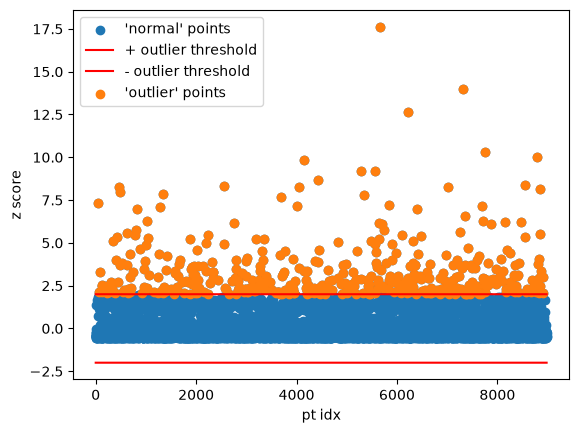

In [9]:
z_scores = z_score(data)
outlier_idxs = np.array([x for x in outliers])
print("num_outliers={0}".format(len(outliers)))

plt.scatter(np.arange(z_scores.shape[0]), z_scores, label="'normal' points")
plt.plot(np.ones_like(z_scores) *  2, color="r", label="+ outlier threshold")
plt.plot(np.ones_like(z_scores) * -2, color="r", label="- outlier threshold")
plt.scatter(outlier_idxs, z_scores[outlier_idxs], label="'outlier' points")
plt.ylabel("z score")
plt.xlabel("pt idx")
plt.legend()
plt.show()

### Problem 2

This problem uses the other provided dataset called "perf.txt." Inside this file are the results of a 12-fold cross validation experiment that I did off-camera. Each of these numbers are the performance of a trained model on a fold of data with larger values being considered better. Each column represents a different model and each row represents a different fold. Therefore a single number in this data is the performance of a specific model on a specific fold.

This data set is small and your code should run instantly with it, but you will be able to use the same code and techniques with larger data sets.

In [10]:
# please don't change this
def load_cv() -> np.ndarray:
    return np.loadtxt("perf.txt", delimiter=",")

In [11]:
performances = load_cv()
print(performances)

[[0.66142  0.649655]
 [0.656604 0.651948]
 [0.65047  0.650936]
 [0.666336 0.64697 ]
 [0.685282 0.650646]
 [0.684663 0.65298 ]
 [0.677166 0.654323]
 [0.64743  0.657978]
 [0.639121 0.655885]
 [0.649021 0.652126]
 [0.641169 0.647335]
 [0.684656 0.655204]]


Please complete the function called `get_t_stat` which calculates the $t$-value of the provided data.

In [24]:
def get_t_stat(model_A_scores: np.ndarray, model_B_scores: np.ndarray) -> float:

    diff =  model_A_scores - model_B_scores

    meanDiff = np.mean(diff)

    var = np.var(diff, ddof=1)

    size = diff.size

    t_value = meanDiff / (np.sqrt(var/size))
    
    return t_value

In [26]:
t = get_t_stat(performances[:, 0], performances[:, 1])
assert(np.isclose(t, 1.9211432))